# SoccerTwos Training Curves

Run this notebook after syncing `ray_results/` from PACE. It selects the newest `progress.csv` for each experiment and writes report-ready plots to `report_plots/`.

In [9]:
from pathlib import Path
import os

os.environ.setdefault("MPLCONFIGDIR", "report_plots/.matplotlib")

import matplotlib.pyplot as plt
import pandas as pd

RAY_RESULTS = Path("ray_results")
OUT_DIR = Path("report_plots")
OUT_DIR.mkdir(parents=True, exist_ok=True)

SMOOTH_WINDOW = 5

In [10]:
def latest_progress_files(ray_results: Path):
    candidates = {
        "Baseline": "PPO_selfplay_baseline",
        "Reward Shaping": "PPO_selfplay_shaped",
        "Self-Play Archive": "PPO_selfplay_rec",
        "Curriculum": "PPO_curriculum_multiagent",
    }
    selected = {}
    for label, dirname in candidates.items():
        paths = list((ray_results / dirname).glob("*/progress.csv"))
        if paths:
            selected[label] = max(paths, key=lambda p: p.stat().st_mtime)
    return selected


progress_files = latest_progress_files(RAY_RESULTS)
progress_files

{'Baseline': PosixPath('ray_results/PPO_selfplay_baseline/PPO_Soccer_65438_00000_0_2026-04-21_17-59-40/progress.csv'),
 'Reward Shaping': PosixPath('ray_results/PPO_selfplay_shaped/PPO_Soccer_d5022_00000_0_2026-04-21_18-24-16/progress.csv'),
 'Self-Play Archive': PosixPath('ray_results/PPO_selfplay_rec/PPO_Soccer_32674_00000_0_2026-04-21_19-24-09/progress.csv'),
 'Curriculum': PosixPath('ray_results/PPO_curriculum_multiagent/PPO_Soccer_6efa0_00000_0_2026-04-21_17-24-09/progress.csv')}

In [11]:
runs = {}
summary_rows = []

for label, path in progress_files.items():
    df = pd.read_csv(path)
    if df.empty or "episode_reward_mean" not in df:
        continue
    runs[label] = df
    last = df.iloc[-1]
    summary_rows.append({
        "agent": label,
        "path": str(path),
        "training_iteration": last.get("training_iteration"),
        "timesteps_total": last.get("timesteps_total"),
        "episodes_total": last.get("episodes_total"),
        "episode_reward_mean": last.get("episode_reward_mean"),
        "episode_reward_min": last.get("episode_reward_min"),
        "episode_reward_max": last.get("episode_reward_max"),
        "time_total_s": last.get("time_total_s"),
    })

summary = pd.DataFrame(summary_rows)
summary.to_csv(OUT_DIR / "training_summary.csv", index=False)
summary

,agent,path,training_iteration,timesteps_total,episodes_total,episode_reward_mean,episode_reward_min,episode_reward_max,time_total_s
0,Baseline,ray_results/PPO_selfplay_baseline/PPO_Soccer_6...,159,1259040,1736,-0.417912,-1.866000,0.000000,8831.417481
1,Reward Shaping,ray_results/PPO_selfplay_shaped/PPO_Soccer_d50...,167,1246673,2136,0.848503,-1.686818,4.874821,7344.128156
2,Self-Play Archive,ray_results/PPO_selfplay_rec/PPO_Soccer_32674_...,62,487606,604,-0.304904,-1.983600,0.000000,3787.320959
3,Curriculum,ray_results/PPO_curriculum_multiagent/PPO_Socc...,239,1827279,3006,2.073014,-0.627589,6.800599,10927.869283


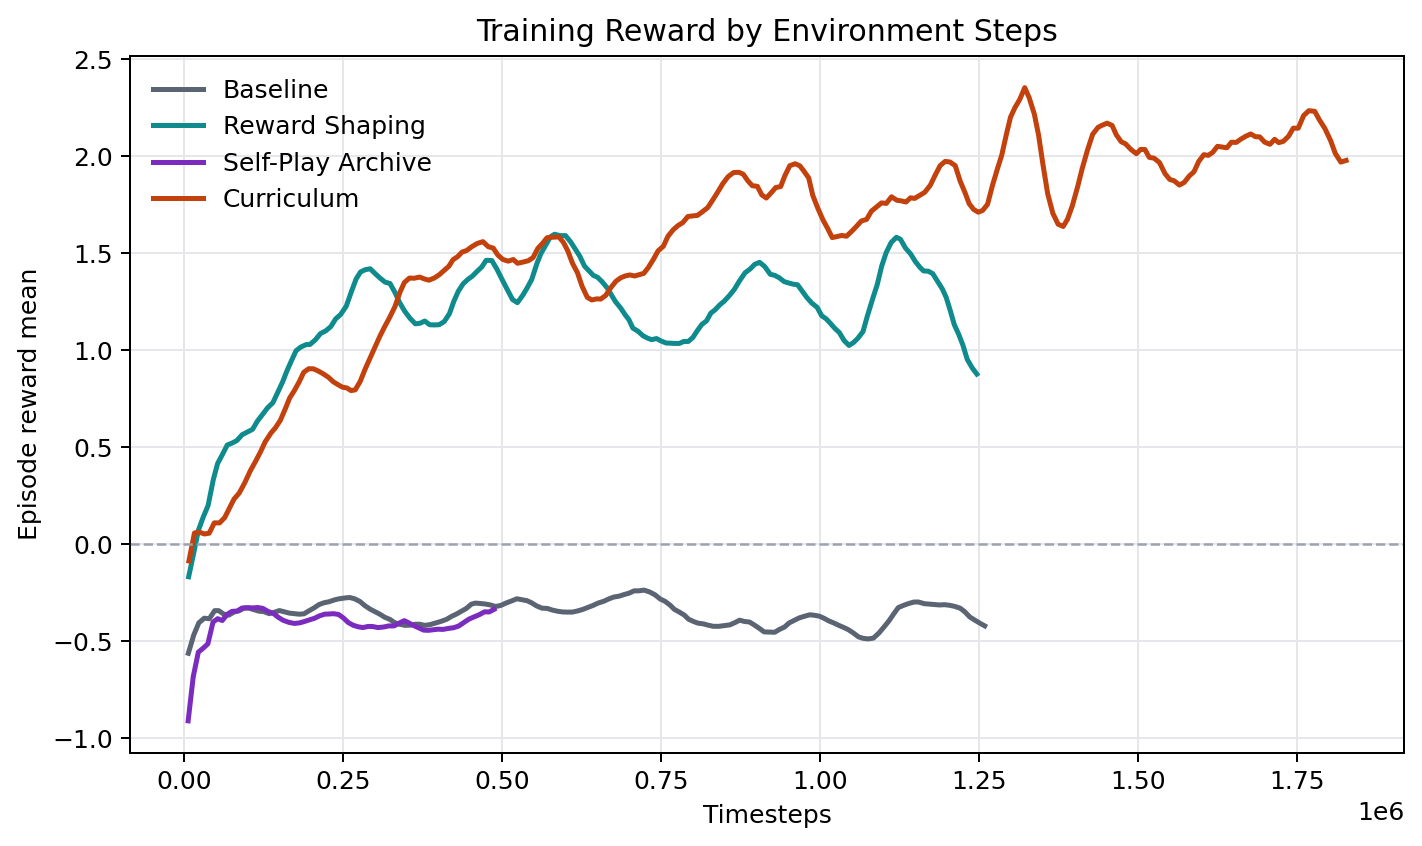

In [12]:
colors = {
    "Baseline": "#5b6472",
    "Reward Shaping": "#0f8b8d",
    "Self-Play Archive": "#7b2cbf",
    "Curriculum": "#c2410c",
}

fig, ax = plt.subplots(figsize=(8, 4.8), dpi=180)
for label, df in runs.items():
    x = df["timesteps_total"] if "timesteps_total" in df else df.index
    y = df["episode_reward_mean"].rolling(SMOOTH_WINDOW, min_periods=1).mean()
    ax.plot(x, y, label=label, linewidth=2.0, color=colors.get(label))

ax.axhline(0, color="#9ca3af", linewidth=1, linestyle="--")
ax.set_title("Training Reward by Environment Steps")
ax.set_xlabel("Timesteps")
ax.set_ylabel("Episode reward mean")
ax.grid(True, color="#e5e7eb", linewidth=0.8)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(OUT_DIR / "reward_vs_timesteps.png")
plt.show()

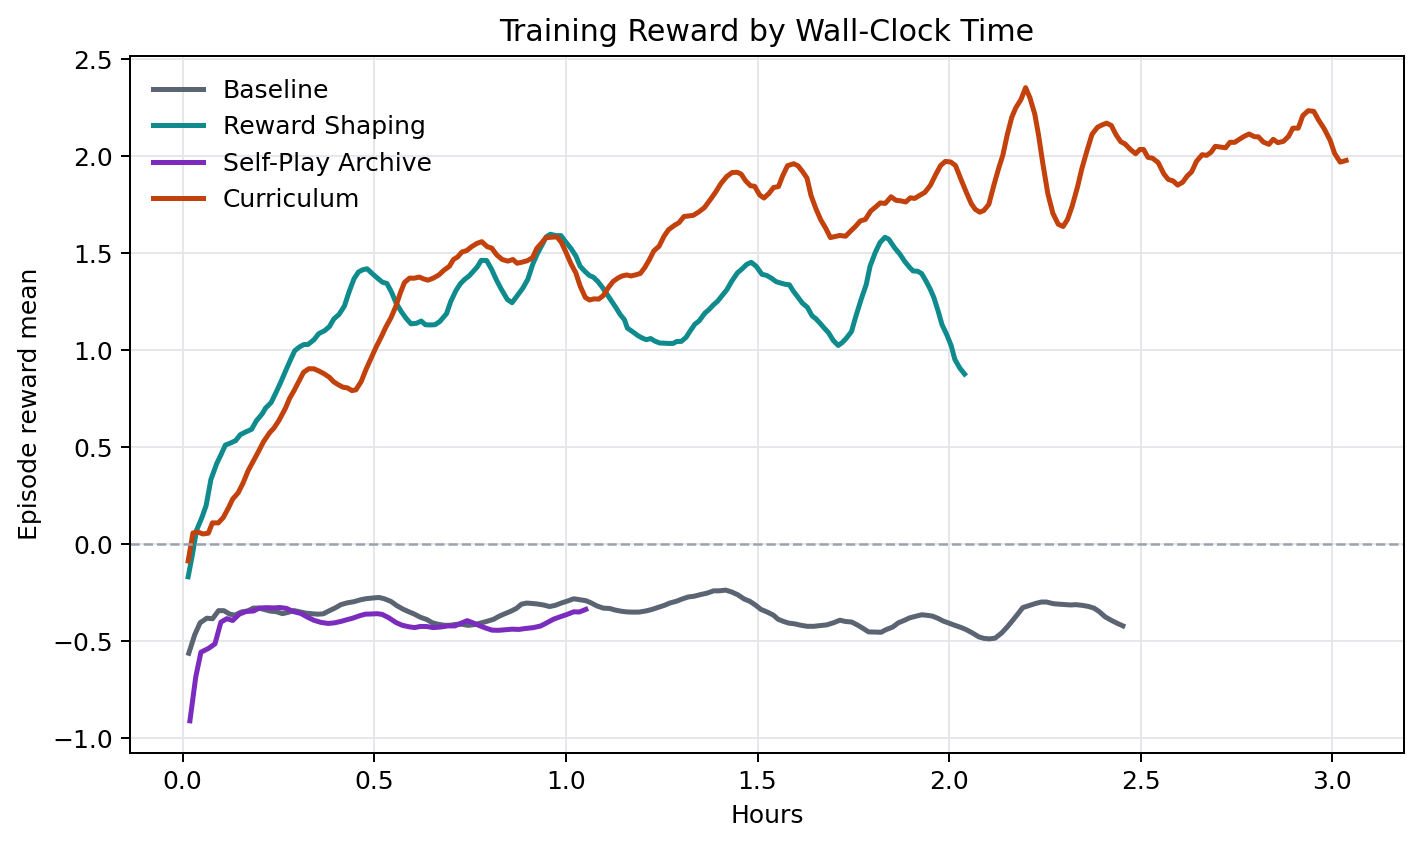

In [13]:
fig, ax = plt.subplots(figsize=(8, 4.8), dpi=180)
for label, df in runs.items():
    if "time_total_s" not in df:
        continue
    x = df["time_total_s"] / 3600.0
    y = df["episode_reward_mean"].rolling(SMOOTH_WINDOW, min_periods=1).mean()
    ax.plot(x, y, label=label, linewidth=2.0, color=colors.get(label))

ax.axhline(0, color="#9ca3af", linewidth=1, linestyle="--")
ax.set_title("Training Reward by Wall-Clock Time")
ax.set_xlabel("Hours")
ax.set_ylabel("Episode reward mean")
ax.grid(True, color="#e5e7eb", linewidth=0.8)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(OUT_DIR / "reward_vs_time.png")
plt.show()

In [14]:
print("Wrote:")
for path in [
    OUT_DIR / "training_summary.csv",
    OUT_DIR / "reward_vs_timesteps.png",
    OUT_DIR / "reward_vs_time.png",
]:
    print(path)

Wrote:
report_plots/training_summary.csv
report_plots/reward_vs_timesteps.png
report_plots/reward_vs_time.png
